
Importation des bibliothèques de base pour l’analyse et la visualisation



In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

In [4]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("zeesolver/consumer-behavior-and-shopping-habits-dataset")

print("Path to dataset files:", path)

100%|██████████| 146k/146k [00:00<00:00, 476kB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/zeesolver/consumer-behavior-and-shopping-habits-dataset/versions/1


Chargement du jeu de données et aperçu des premières lignes

In [6]:
import os
file_path = os.path.join(path, 'shopping_behavior_updated.csv')
df = pd.read_csv(file_path)
df.head(10)

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually
5,6,46,Male,Sneakers,Footwear,20,Wyoming,M,White,Summer,2.9,Yes,Standard,Yes,Yes,14,Venmo,Weekly
6,7,63,Male,Shirt,Clothing,85,Montana,M,Gray,Fall,3.2,Yes,Free Shipping,Yes,Yes,49,Cash,Quarterly
7,8,27,Male,Shorts,Clothing,34,Louisiana,L,Charcoal,Winter,3.2,Yes,Free Shipping,Yes,Yes,19,Credit Card,Weekly
8,9,26,Male,Coat,Outerwear,97,West Virginia,L,Silver,Summer,2.6,Yes,Express,Yes,Yes,8,Venmo,Annually
9,10,57,Male,Handbag,Accessories,31,Missouri,M,Pink,Spring,4.8,Yes,2-Day Shipping,Yes,Yes,4,Cash,Quarterly


Affichage des noms des colonnes du dataset


In [12]:
df.columns

Index(['customer_id', 'age', 'gender', 'item_purchased', 'category',
       'purchase_amount_usd', 'location', 'size', 'color', 'season',
       'review_rating', 'subscription_status', 'shipping_type',
       'discount_applied', 'promo_code_used', 'previous_purchases',
       'payment_method', 'frequency_of_purchases'],
      dtype='object')

Renommage des colonnes pour une meilleure lisibilité

In [9]:
df.rename(columns={'Customer ID': 'customer_id',
         'Age': 'age',
         'Gender': 'gender',
         'Item Purchased': 'item_purchased',
         'Category': 'category',
         'Purchase Amount (USD)': 'purchase_amount_usd',
         'Location': 'location',
         'Size': 'size',
         'Color': 'color',
         'Season': 'season',
         'Review Rating': 'review_rating',
         'Subscription Status': 'subscription_status',
         'Shipping Type': 'shipping_type',
         'Discount Applied': 'discount_applied',
         'Promo Code Used': 'promo_code_used',
         'Previous Purchases': 'previous_purchases',
         'Payment Method': 'payment_method',
         'Frequency of Purchases': 'frequency_of_purchases'}, inplace=True)

Informations générales sur la structure du dataset


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   customer_id             3900 non-null   int64  
 1   age                     3900 non-null   int64  
 2   gender                  3900 non-null   object 
 3   item_purchased          3900 non-null   object 
 4   category                3900 non-null   object 
 5   purchase_amount_usd     3900 non-null   int64  
 6   location                3900 non-null   object 
 7   size                    3900 non-null   object 
 8   color                   3900 non-null   object 
 9   season                  3900 non-null   object 
 10  review_rating           3900 non-null   float64
 11  subscription_status     3900 non-null   object 
 12  shipping_type           3900 non-null   object 
 13  discount_applied        3900 non-null   object 
 14  promo_code_used         3900 non-null   

Détection des valeurs manquantes dans le jeu de données

In [13]:
df.isnull().sum().sort_values(ascending=False)

,0
customer_id,0
age,0
gender,0
item_purchased,0
category,0
purchase_amount_usd,0
location,0
size,0
color,0
season,0


Aperçu final du dataset après nettoyage initial

In [14]:
df.head()

,customer_id,age,gender,item_purchased,category,purchase_amount_usd,location,size,color,season,review_rating,subscription_status,shipping_type,discount_applied,promo_code_used,previous_purchases,payment_method,frequency_of_purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


modelisation

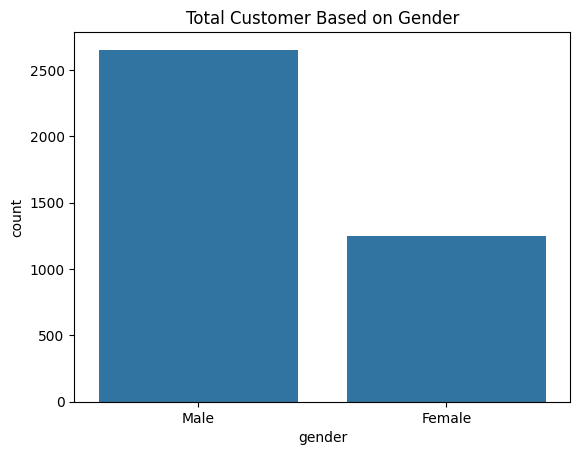

In [15]:
plt.title('Total Customer Based on Gender')
sns.countplot(df, x='gender');

/tmp/ipython-input-1718017640.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(male_cust, x=male_cust['age'], palette='mako');


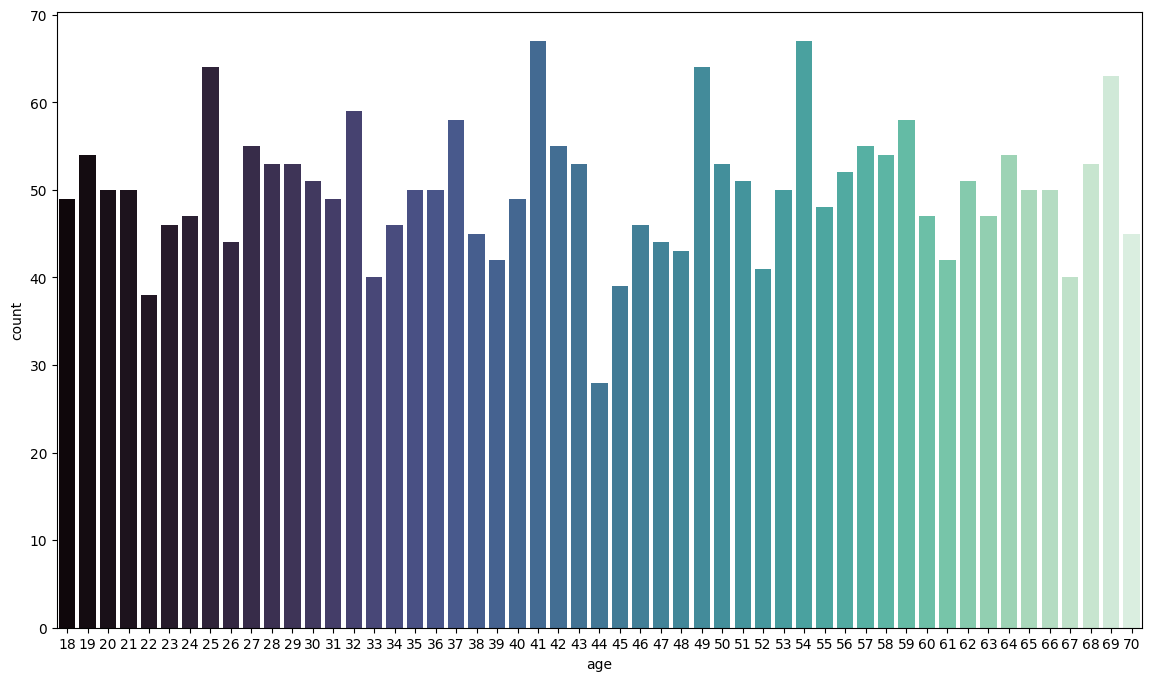

In [16]:
# Male customer age (sorted from lowest to highest)
male_cust = df[df['gender'] == 'Male'];
plt.figure(figsize=(14,8));
sns.countplot(male_cust, x=male_cust['age'], palette='mako');

In [17]:
# Top 5 from the highest count of Age Customer (male)
male_cust['age'].value_counts(ascending=False).head()

,count
age,
54,67
41,67
49,64
25,64
69,63


/tmp/ipython-input-1261983802.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(female_cust, x=female_cust['age'], palette='inferno');


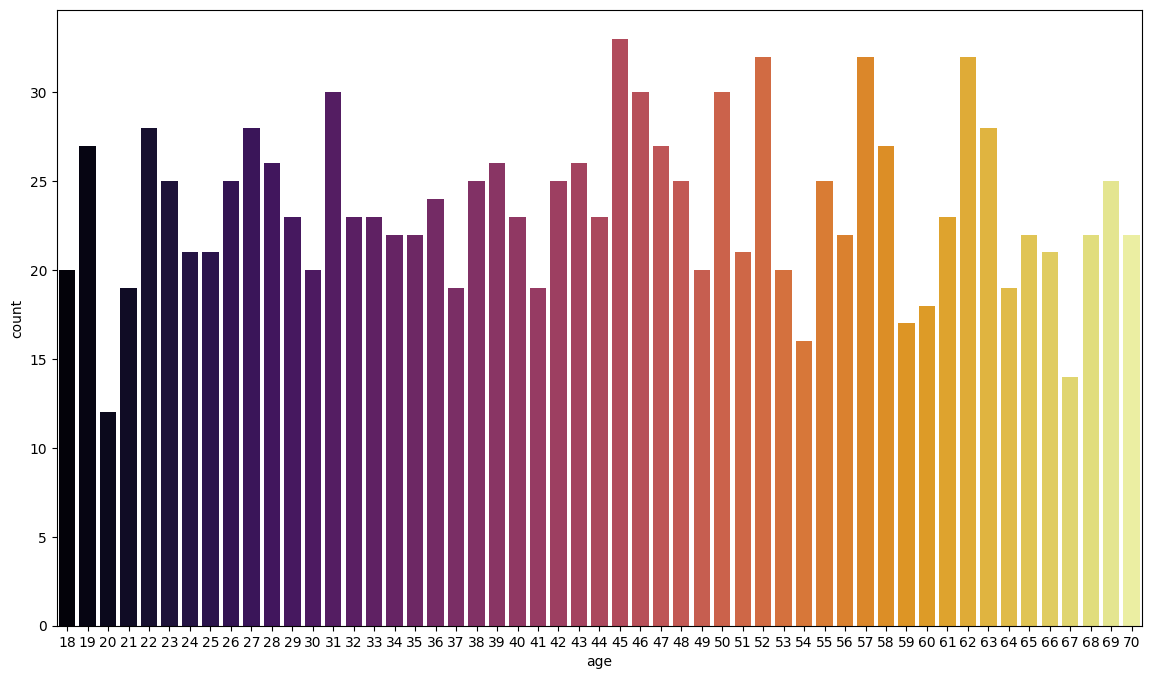

In [18]:
# Female customer age (sorted from lowest to highest)
female_cust = df[df['gender'] == 'Female'];
plt.figure(figsize=(14,8));
sns.countplot(female_cust, x=female_cust['age'], palette='inferno');

In [19]:
# Top 5 from the highest count of Age Customer (female)
female_cust['age'].value_counts(ascending=False).head()

,count
age,
45,33
52,32
57,32
62,32
46,30


In [20]:
top5_male = male_cust[(male_cust['age'] == 41) | (male_cust['age'] == 54) | (male_cust['age'] == 49) | (male_cust['age'] == 25) | (male_cust['age'] == 69)]
top5_male.head()

,customer_id,age,gender,item_purchased,category,purchase_amount_usd,location,size,color,season,review_rating,subscription_status,shipping_type,discount_applied,promo_code_used,previous_purchases,payment_method,frequency_of_purchases
16,17,25,Male,Sunglasses,Accessories,36,Alabama,S,Gray,Spring,4.1,Yes,Next Day Air,Yes,Yes,44,Debit Card,Bi-Weekly
28,29,54,Male,Handbag,Accessories,94,North Carolina,M,Gray,Fall,4.4,Yes,Free Shipping,Yes,Yes,41,PayPal,Every 3 Months
33,34,54,Male,Pants,Clothing,38,Colorado,L,Green,Summer,3.3,Yes,Store Pickup,Yes,Yes,45,Cash,Quarterly
35,36,54,Male,Blouse,Clothing,33,Massachusetts,M,Cyan,Summer,4.0,Yes,2-Day Shipping,Yes,Yes,48,Credit Card,Bi-Weekly
40,41,69,Male,Handbag,Accessories,76,Louisiana,L,Beige,Winter,4.6,Yes,Next Day Air,Yes,Yes,31,Debit Card,Quarterly


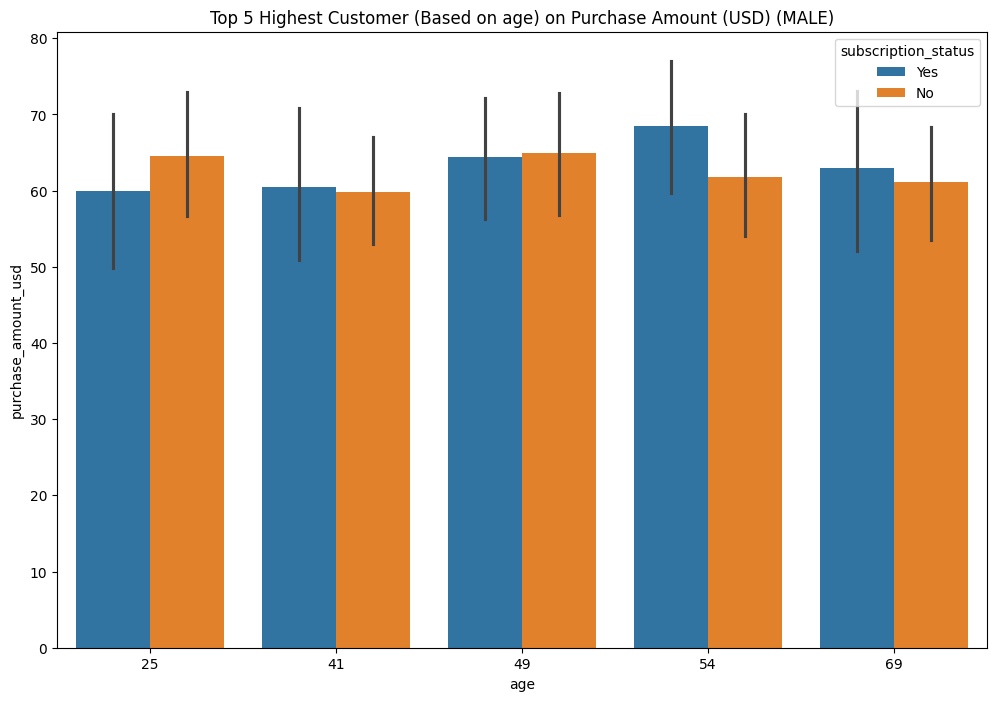

In [21]:
plt.figure(figsize=(12,8));
plt.title('Top 5 Highest Customer (Based on age) on Purchase Amount (USD) (MALE)');
sns.barplot(top5_male, x='age', y='purchase_amount_usd', hue='subscription_status');

In [22]:
top5_female = female_cust[(female_cust['age'] == 45) | (female_cust['age'] == 62) | (female_cust['age'] == 52) | (female_cust['age'] == 57)
                          | (female_cust['age'] == 31)]
top5_female.head()

,customer_id,age,gender,item_purchased,category,purchase_amount_usd,location,size,color,season,review_rating,subscription_status,shipping_type,discount_applied,promo_code_used,previous_purchases,payment_method,frequency_of_purchases
2656,2657,52,Female,Shorts,Clothing,76,Indiana,L,Yellow,Winter,3.6,No,Express,No,No,29,Bank Transfer,Fortnightly
2657,2658,52,Female,Dress,Clothing,81,Texas,M,Pink,Summer,2.7,No,Express,No,No,7,Credit Card,Fortnightly
2658,2659,52,Female,Handbag,Accessories,47,Ohio,XL,Indigo,Summer,3.2,No,Next Day Air,No,No,39,PayPal,Monthly
2677,2678,45,Female,Shorts,Clothing,43,Connecticut,L,Olive,Spring,3.8,No,Next Day Air,No,No,6,PayPal,Every 3 Months
2696,2697,57,Female,Coat,Outerwear,20,South Dakota,M,White,Spring,4.7,No,Free Shipping,No,No,12,Debit Card,Monthly


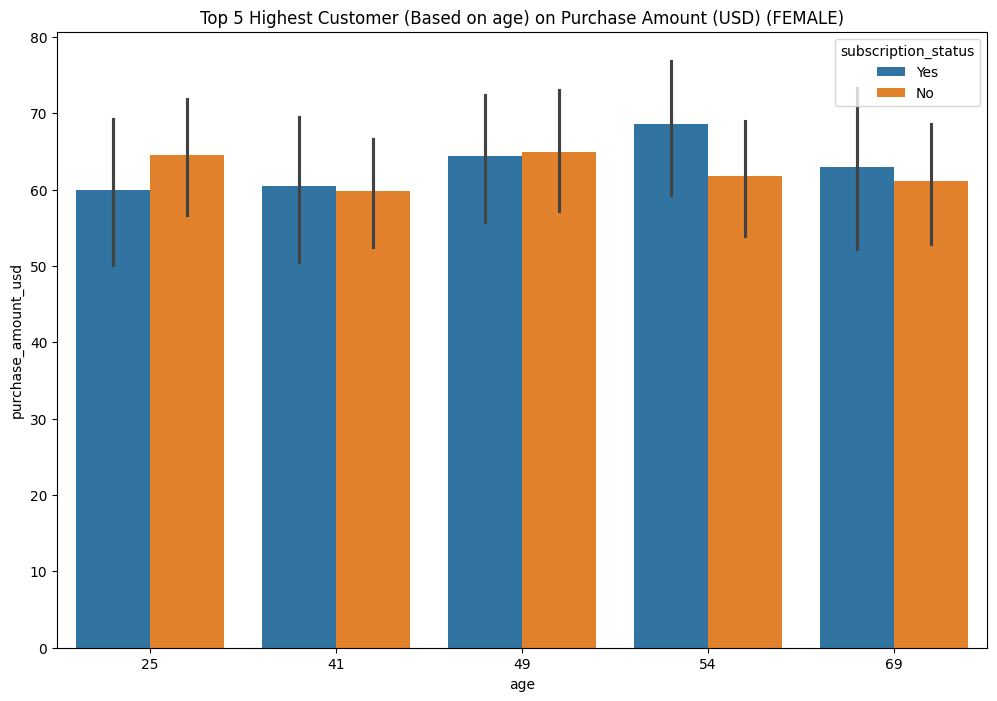

In [23]:
plt.figure(figsize=(12,8));
plt.title('Top 5 Highest Customer (Based on age) on Purchase Amount (USD) (FEMALE)');
sns.barplot(top5_male, x='age', y='purchase_amount_usd', hue='subscription_status');

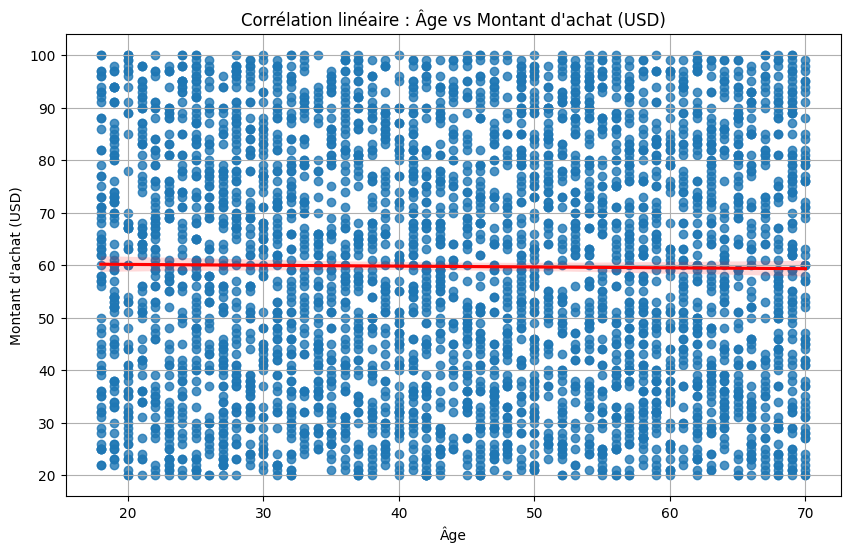

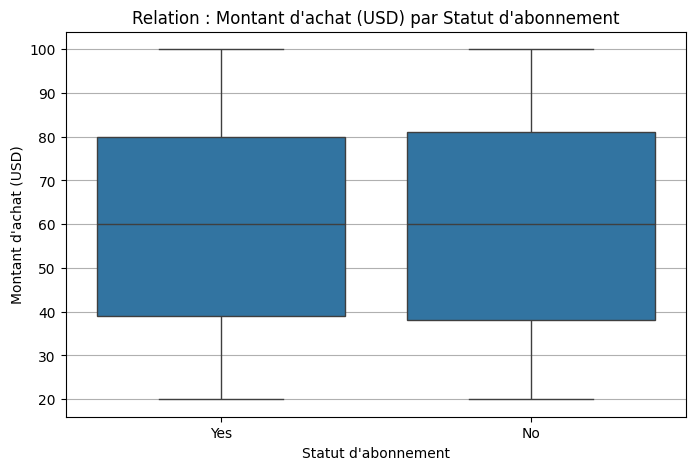

In [24]:
# Linear correlation graph: Age vs Purchase Amount
plt.figure(figsize=(10, 6))
sns.regplot(x='age', y='purchase_amount_usd', data=df, line_kws={"color": "red"})
plt.title('Corrélation linéaire : Âge vs Montant d\'achat (USD)')
plt.xlabel('Âge')
plt.ylabel('Montant d\'achat (USD)')
plt.grid(True)
plt.show()

# Logistic correlation graph interpretation: Purchase Amount vs Subscription Status
# Using a boxplot to show the distribution of purchase amounts for each subscription status
plt.figure(figsize=(8, 5))
sns.boxplot(x='subscription_status', y='purchase_amount_usd', data=df)
plt.title('Relation : Montant d\'achat (USD) par Statut d\'abonnement')
plt.xlabel('Statut d\'abonnement')
plt.ylabel('Montant d\'achat (USD)')
plt.grid(axis='y')
plt.show()